<a href="https://colab.research.google.com/github/wingated/cs473/blob/main/mini_labs/week_4_empirical_risk.ipynb"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# BYU CS 473 — Empirical Risk Minimization and Model Evaluation

In this assignment, you will learn how empirical risk minimization relates to model performance, and how concepts like approximation error, estimation error, regularization, structural risk minimization, and cross-validation help build better models.

---

## Learning Goals
- Understand **approximation error** vs **estimation error**
- Understand **regularized risk minimization**
- Understand **structural risk minimization**
- Apply **cross-validation** to evaluate models


## 1. Empirical Risk & Error Decomposition

- **Empirical Risk Minimization (ERM):** we choose a hypothesis that minimizes the average loss on training data.  
- **Approximation Error:** error due to limited model class (e.g., linear models can’t fit curved patterns).  
- **Estimation Error:** error due to limited data or overfitting.

$\text{Total Error} = \text{Approximation Error} + \text{Estimation Error}$


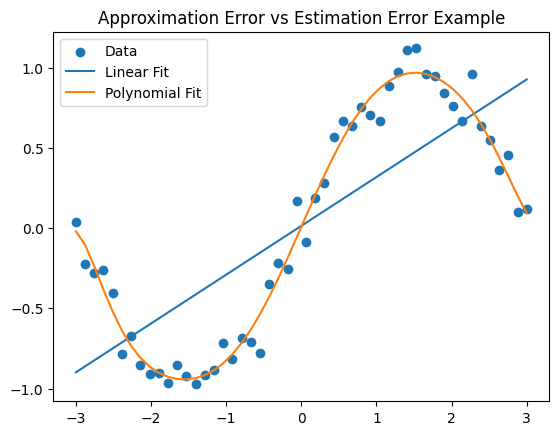

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

# Generate nonlinear data
np.random.seed(0)
X = np.linspace(-3, 3, 50).reshape(-1, 1)
y = np.sin(X) + np.random.normal(0, 0.1, X.shape)

# Linear fit (high approx. error, low est. error)
lin = LinearRegression().fit(X, y)
y_lin = lin.predict(X)

# Polynomial fit (low approx. error, higher est. error risk)
poly = PolynomialFeatures(degree=10)
X_poly = poly.fit_transform(X)
lin_poly = LinearRegression().fit(X_poly, y)
y_poly = lin_poly.predict(X_poly)

plt.scatter(X, y, label="Data")
plt.plot(X, y_lin, label="Linear Fit")
plt.plot(X, y_poly, label="Polynomial Fit")
plt.legend()
plt.title("Approximation Error vs Estimation Error Example")
plt.show()


### Exercise 1
- Fit polynomial models of degree 2, 5, and 15 to the same data.  
- Compare their training error and test error (use a held-out test set).  
- Which models show more approximation error? Which show more estimation error?


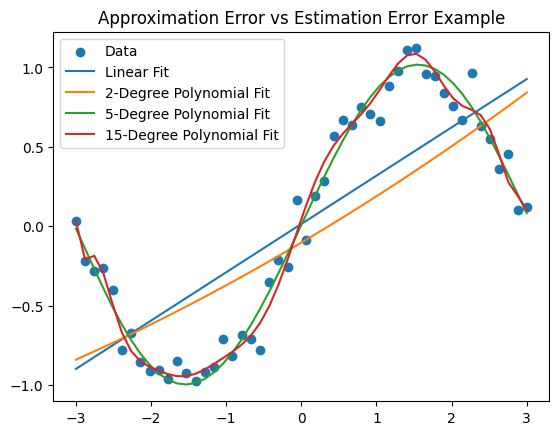

Degree 2
Training MSE: 0.20987574492723882
Test MSE: 0.20686427368830002

Degree 5
Training MSE: 0.01197291034806437
Test MSE: 0.008876135573666514

Degree 15
Training MSE: 0.009199112933543795
Test MSE: 0.009274059100162024


In [6]:
# Your code here
# Create test/train split.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

# 2-Degree Polynomial fit.
two_poly = PolynomialFeatures(degree=2)
X_train_two_poly = two_poly.fit_transform(X_train)
X_test_two_poly = two_poly.transform(X_test)
lin_two_poly = LinearRegression().fit(X_train_two_poly, y_train)

train_error_two_poly = mean_squared_error(y_train, lin_two_poly.predict(X_train_two_poly))
test_error_two_poly = mean_squared_error(y_test, lin_two_poly.predict(X_test_two_poly))

# 5-Degree Polynomial fit.
five_poly = PolynomialFeatures(degree=5)
X_train_five_poly = five_poly.fit_transform(X_train)
X_test_five_poly = five_poly.transform(X_test)
lin_five_poly = LinearRegression().fit(X_train_five_poly, y_train)

train_error_five_poly = mean_squared_error(y_train, lin_five_poly.predict(X_train_five_poly))
test_error_five_poly = mean_squared_error(y_test, lin_five_poly.predict(X_test_five_poly))

# 15-Degree Polynomial fit.
fifteen_poly = PolynomialFeatures(degree=15)
X_train_fifteen_poly = fifteen_poly.fit_transform(X_train)
X_test_fifteen_poly = fifteen_poly.transform(X_test)
lin_fifteen_poly = LinearRegression().fit(X_train_fifteen_poly, y_train)

# Generate predictions (for plotting purposes -- I'm not sure if we need a plot).
X_two_poly = two_poly.transform(X)
X_five_poly = five_poly.transform(X)
X_fifteen_poly = fifteen_poly.transform(X)

y_two_poly = lin_two_poly.predict(X_two_poly)
y_five_poly = lin_five_poly.predict(X_five_poly)
y_fifteen_poly = lin_fifteen_poly.predict(X_fifteen_poly)

train_error_fifteen_poly = mean_squared_error(y_train, lin_fifteen_poly.predict(X_train_fifteen_poly))
test_error_fifteen_poly = mean_squared_error(y_test, lin_fifteen_poly.predict(X_test_fifteen_poly))

plt.scatter(X, y, label="Data")
plt.plot(X, y_lin, label="Linear Fit")
plt.plot(X, y_two_poly, label="2-Degree Polynomial Fit")
plt.plot(X, y_five_poly, label="5-Degree Polynomial Fit")
plt.plot(X, y_fifteen_poly, label="15-Degree Polynomial Fit")
plt.legend()
plt.title("Approximation Error vs Estimation Error Example")
plt.show()

# Print errors (for write-up).
print("Degree 2")
print("Training MSE:", train_error_two_poly)
print("Test MSE:", test_error_two_poly)

print("\nDegree 5")
print("Training MSE:", train_error_five_poly)
print("Test MSE:", test_error_five_poly)

print("\nDegree 15")
print("Training MSE:", train_error_fifteen_poly)
print("Test MSE:", test_error_fifteen_poly)

1. The lower-degree models show more approximation error.  This is because they lack the degrees of freedom necessary to closely follow the changing curves over time of the sample data.  More technically speaking, their hypothesis class is too restrictive to capture the underlying nonlinear relationship.  Higher-order polynomials are able to more closely model these non-linear, continuous functions.

2. The higher-degree models show more estimation error.  This is because their additional flexibility (discussed in (1)) also allow them to fit sample-specific noise, meaning that low training may not necessarily translate into equally low error on unseen data (i.e., the model is overfit to the noise, rather than to the inherent underlying function).

## 2. Regularized Risk

To reduce overfitting, we add a penalty term to the empirical risk:

$R_{\text{reg}}(h) = R_{\text{emp}}(h) + \lambda \cdot \Omega(h)$

- $R_{\text{emp}}$: training error  
- $\Omega(h)$: complexity of hypothesis (e.g., large weights)  
- $\lambda$: regularization strength  

Examples: **Ridge (L2)**, **Lasso (L1)**.


In [7]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=0)

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=0.1, max_iter=10000).fit(X_train, y_train)

print("Ridge test error:", mean_squared_error(y_test, ridge.predict(X_test)))
print("Lasso test error:", mean_squared_error(y_test, lasso.predict(X_test)))

Ridge test error: 0.015494279161805081
Lasso test error: 0.055022128422353586


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.740e-02, tolerance: 1.728e-03
  model = cd_fast.enet_coordinate_descent(


In [12]:
lambda_vals = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.3, random_state=0)

for lam in lambda_vals:
    ridge = Ridge(alpha=lam).fit(X_train, y_train)

    print(f'For lambda = {lam}:')
    print("Ridge train error:", mean_squared_error(y_train, ridge.predict(X_train)))
    print("Ridge test error:", mean_squared_error(y_test, ridge.predict(X_test)))
    # print("Lasso test error:", mean_squared_error(y_test, lasso.predict(X_test)))
    print(f'')

For lambda = 0.001:
Ridge train error: 0.011191540105260602
Ridge test error: 0.010519459937082792

For lambda = 0.01:
Ridge train error: 0.011196637463291172
Ridge test error: 0.010397751807405587

For lambda = 0.1:
Ridge train error: 0.011559621990917878
Ridge test error: 0.009857671344362615

For lambda = 1.0:
Ridge train error: 0.01762805736620552
Ridge test error: 0.015494279161805081

For lambda = 10.0:
Ridge train error: 0.05543471390352195
Ridge test error: 0.07503268485492062

For lambda = 100.0:
Ridge train error: 0.1369096407498701
Ridge test error: 0.21151747815925775

For lambda = 1000.0:
Ridge train error: 0.23743145217720807
Ridge test error: 0.35712397776329746



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.740e-02, tolerance: 1.728e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.740e-02, tolerance: 1.728e-03
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.740e-02, tolerance: 1.728e

### Exercise 2
Experiment with different values of λ for Ridge regression.  
- How does increasing λ affect training error?  
- How does it affect test error?  
- Why?


# **FIX**

1. In general (and especially for $\lambda > 1$), increasing $\lambda$ increases the training error because the model increasingly sacrifices training fit in order to keep its coefficients small (since a larger lambda increases the penalty for large coefficients).

2. For small values of $\lambda$ (for the smaller values tested here, such as $\lambda \leq 0.1$), the test error *decreases* slightly before reaching a minimum near $\lambda = 0.1$, before sharply increasing as $\lambda$ increases thereafter.  This indicates that the model becomes over-regularized and underfits.

3. These two impacts occur because increasing lambda controls the tradeoff between empirical fit and model complexity.  Larger values of lambda tend to increase the penalty for large coefficient magnitudes, tending to reduce the effective model complexity.

## 3. Structural Risk Minimization

ERM chooses the best hypothesis within a model class.  
**Structural Risk Minimization (SRM)** considers a sequence of model classes of increasing complexity, balancing fit and capacity.

- Small models → high approximation error, low estimation error.  
- Large models → low approximation error, high estimation error risk.  

SRM chooses the model class with best **generalization**.


### Exercise 3
Train polynomial regressors with degrees from 1 to 15.  
- Plot training and test error against model degree.  
- Which degree minimizes test error?  
- How does this illustrate SRM?


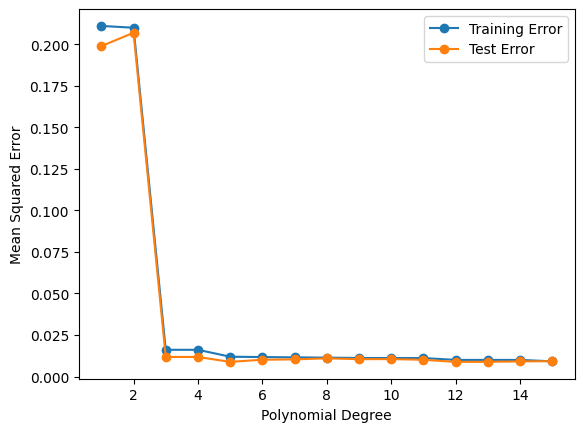

In [15]:
# Your code here
degrees = np.arange(1, 16)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

train_errors = []
test_errors = []

# Train polynomial regressors with degrees from 1-15.
for d in degrees:
    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression().fit(X_train_poly, y_train)
    train_errors.append(mean_squared_error(y_train, model.predict(X_train_poly)))
    test_errors.append(mean_squared_error(y_test, model.predict(X_test_poly)))


plt.plot(degrees, train_errors, marker="o", label="Training Error")
plt.plot(degrees, test_errors, marker="o", label="Test Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Squared Error")
plt.legend()
plt.show()

# **FIX**

1. The degree-12 polynomial regressor minimizes the test set error for this particular train/test split, even though the training error appears to decrease monotonically as the polynomial degree increases.

2. The effect responded to above illustrates SRM by showing that a the polynomial degree that minimizes test error is one with a high enough degree to have a relatively low training error, but is also not of such high degree that it is overfit to the data (leading to a relatively higher test error).  That is, SRM chooses the model that generalizes best, which is often in the "Goldilocks zone" of model sizes -- not too big and not too small.

## 4. Cross-Validation

Cross-validation estimates model performance by splitting data into multiple training/test folds.

- **k-fold cross-validation:** split data into k folds, train on k-1, test on 1, rotate.  
- Provides a more stable estimate of generalization error.  


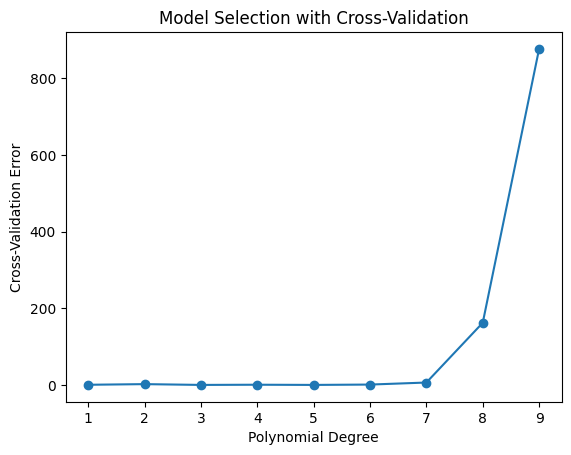

In [16]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import make_pipeline

degrees = range(1, 10)
cv_scores = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    scores = cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error")
    cv_scores.append(-scores.mean())

plt.plot(degrees, cv_scores, marker="o")
plt.xlabel("Polynomial Degree")
plt.ylabel("Cross-Validation Error")
plt.title("Model Selection with Cross-Validation")
plt.show()

### Exercise 4
- Which polynomial degree minimizes cross-validation error?  
- How does this compare to training/test error without cross-validation?  
- Why is cross-validation more reliable?

In [17]:
best_index = np.argmin(cv_scores)
best_degree = list(degrees)[best_index]

print("Best degree:", best_degree)
print("Minimum CV error:", cv_scores[best_index])

Best degree: 3
Minimum CV error: 0.01926246038621423


# **FIX**

1. The degree-3 polynomial minimizes cross-validation error (for verification, please see the `CODE` cell directly above).  Without cross-validation, the best train/test split within the domain of the plot immediately above (i.e., degree $d \in \{1, 2, 3, 4, 5, 6, 7, 8, 9\}$) was degree-5 (see the plot and work in `Exercise 3`), whereas with cross-validation, the polynomial which minimized loss was degree-3.

2. Cross-validation is more reliable because it averages performance over multiple partitions of the data, making the estimate much less sensitive to stochastic noise inherent in each prediction.

## 5. Reflection

### Exercise 5
Answer in 2–3 sentences each:

1. What is the difference between approximation error and estimation error?  
2. How does regularization reduce overfitting?  
3. Why is cross-validation preferred over a single train/test split?


1. Whereas approximation error measures...

2. Regularization reduces overfitting by... .

3. Cross-validation is preferred over a single train/test split because... .